# Main Experiment Notebook
This notebook runs the full pipeline step by step.

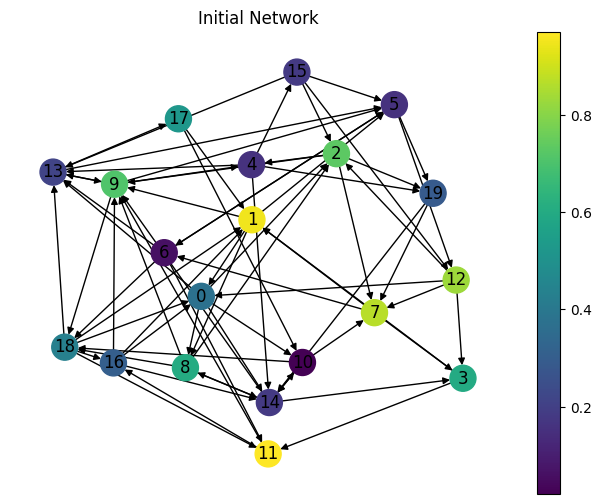

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



Generated Posts and Their Results:
   Post Number                                          Post Text  \
0            1  Amazon prime is better than netflix and only i...   
1            2  Amazon prime is better than netflix in America...   
2            3  Amazon prime is better than netflix.com, but e...   
3            4  Amazon prime is better than netflix because it...   
4            5  Amazon prime is better than netflix in many in...   

   Sentiment Score  Engagement Score  
0              1.0                 5  
1              0.0                 7  
2              0.0                 7  
3              1.0                 5  
4              1.0                 5  

Best Post (Post 2):
Text: Amazon prime is better than netflix in America right now, but it is in small supply. According to TV-viewer statistics from Nielsen, streaming services such as Netflix have about 12 million more people than Amazon.

Netflix's streaming services have helped Hulu and other small-box video-

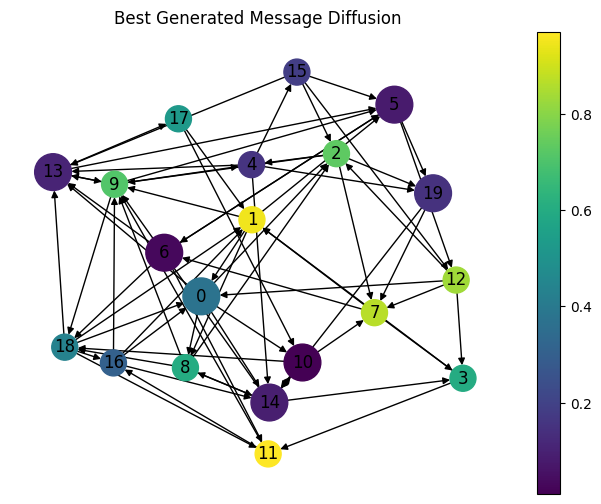


Best Message Value: 0.45
Best Engagement: 14


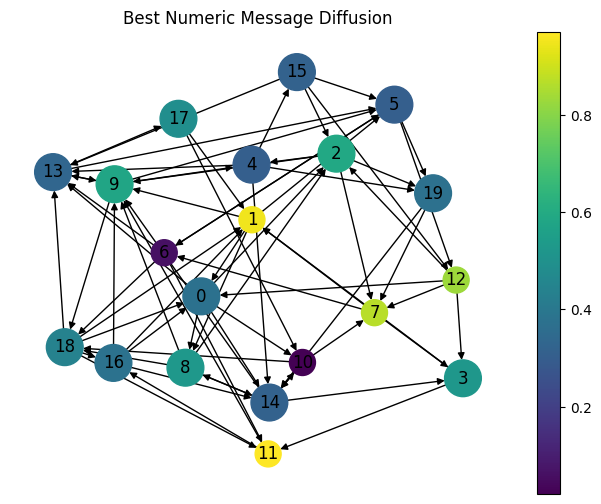

(0.4337969177607446, [(0.5895415141063362, 9), (0.4806896131591356, 11), (0.4806896131591356, 11), (0.4337969177607446, 14), (0.4337969177607446, 14), (0.4337969177607446, 14), (0.4337969177607446, 14), (0.4337969177607446, 14)])

PPO Optimization History:
[(0.025010755222666936, 7), (0.1418636200067911, 9), (0.1418636200067911, 9), (0.1418636200067911, 9), (0.22900844221693353, 10), (0.3219395004352519, 11), (0.3219395004352519, 11), (0.3204504435627057, 12)]


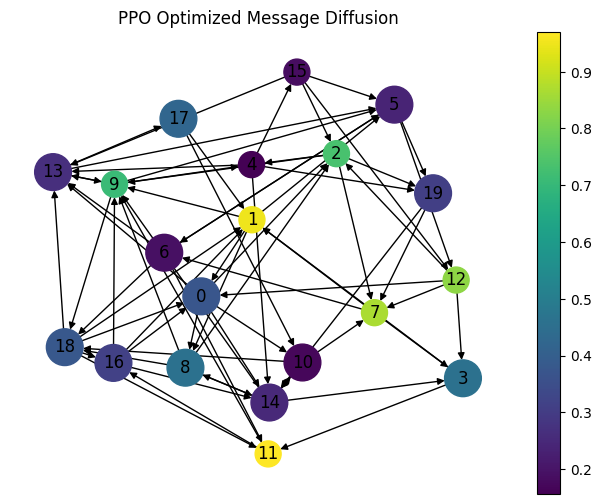

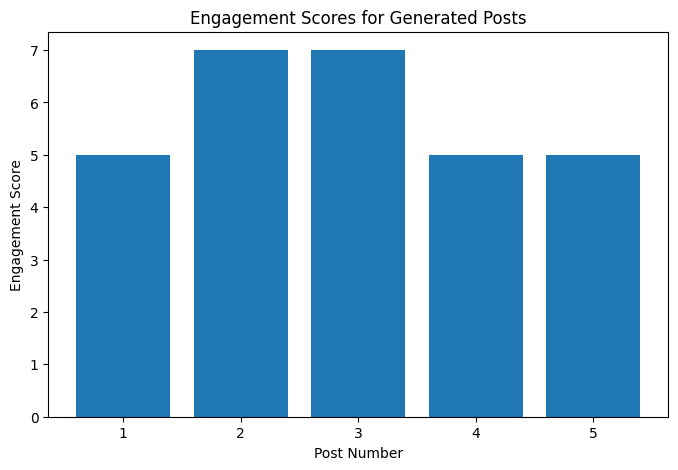

In [5]:

import sys, os
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath('../'))

from src.graph import create_graph
from src.visualization import plot_graph
from src.experiments import test_single_prompt, propagate
from src.optimization import search_best_message, lightweight_ppo

# Step 1: Create graph
G, opinions = create_graph()

# Step 2: Visualize
plot_graph(G, opinions, title='Initial Network')

# Step 3: User input for prompt
prompt = input("Enter your prompt for content generation: ")

# Generate multiple posts for the prompt
results_df = test_single_prompt(G, opinions, prompt, num_posts=5)

print("\nGenerated Posts and Their Results:")
print(results_df[["Post Number", "Post Text", "Sentiment Score", "Engagement Score"]])

# Find the best post
best_post_row = results_df.sort_values("Engagement Score", ascending=False).iloc[0]

print(f"\nBest Post (Post {best_post_row['Post Number']}):")
print(f"Text: {best_post_row['Post Text']}")
print(f"Sentiment: {best_post_row['Sentiment Score']}")
print(f"Engagement: {best_post_row['Engagement Score']}")

plot_graph(
    G,
    best_post_row["Updated Opinions"],
    activated_nodes=best_post_row["Activated Nodes"],
    title="Best Generated Message Diffusion"
)


# Step 4: Brute-force search
best_value, best_score, best_nodes, best_updated = search_best_message(G, opinions)

print("\nBest Message Value:", round(best_value, 3))
print("Best Engagement:", best_score)

plot_graph(
    G,
    best_updated,
    activated_nodes=best_nodes,
    title="Best Numeric Message Diffusion"
)

# Step 5: PPO optimization
print(lightweight_ppo(G, opinions))

ppo_message, ppo_history = lightweight_ppo(G, opinions)

print("\nPPO Optimization History:")
print(ppo_history)

ppo_score, ppo_updated, ppo_nodes = propagate(G, opinions, ppo_message)

plot_graph(
    G,
    ppo_updated,
    activated_nodes=ppo_nodes,
    title="PPO Optimized Message Diffusion"
)

plt.figure(figsize=(8, 5))
plt.bar(results_df["Post Number"].astype(str), results_df["Engagement Score"])
plt.xlabel("Post Number")
plt.ylabel("Engagement Score")
plt.title("Engagement Scores for Generated Posts")
plt.show()